In [3]:
import torch
import pandas as pd
import numpy as np

print("PyTorch versiyon:", torch.__version__)
print("Pandas versiyon:", pd.__version__)
print("Numpy versiyon:", np.__version__)
print("Hazırız!")

PyTorch versiyon: 2.10.0+cpu
Pandas versiyon: 3.0.1
Numpy versiyon: 2.4.3
Hazırız!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükle
df = pd.read_csv('dataset.csv')

# Genel bakış
print("Satır sayısı:", len(df))
print("Sütun sayısı:", len(df.columns))
print("\nSütunlar:")
print(df.columns.tolist())


Satır sayısı: 114000
Sütun sayısı: 21

Sütunlar:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [ ]:

df.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# Eksik veri var mı kontrol et
print(df.isnull().sum())

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [4]:
# Müzik özelliklerinin genel istatistikleri
features = ['danceability', 'energy', 'valence', 
            'tempo', 'acousticness', 'instrumentalness',
            'speechiness', 'loudness', 'liveness']

df[features].describe()


,danceability,energy,valence,tempo,acousticness,instrumentalness,speechiness,loudness,liveness
count,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,0.566800,0.641383,0.474068,122.147837,0.314910,0.156050,0.084652,-8.258960,0.213553
std,0.173542,0.251529,0.259261,29.978197,0.332523,0.309555,0.105732,5.029337,0.190378
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-49.531000,0.000000
25%,0.456000,0.472000,0.260000,99.218750,0.016900,0.000000,0.035900,-10.013000,0.098000
50%,0.580000,0.685000,0.464000,122.017000,0.169000,0.000042,0.048900,-7.004000,0.132000
75%,0.695000,0.854000,0.683000,140.071000,0.598000,0.049000,0.084500,-5.003000,0.273000
max,0.985000,1.000000,0.995000,243.372000,0.996000,1.000000,0.965000,4.532000,1.000000


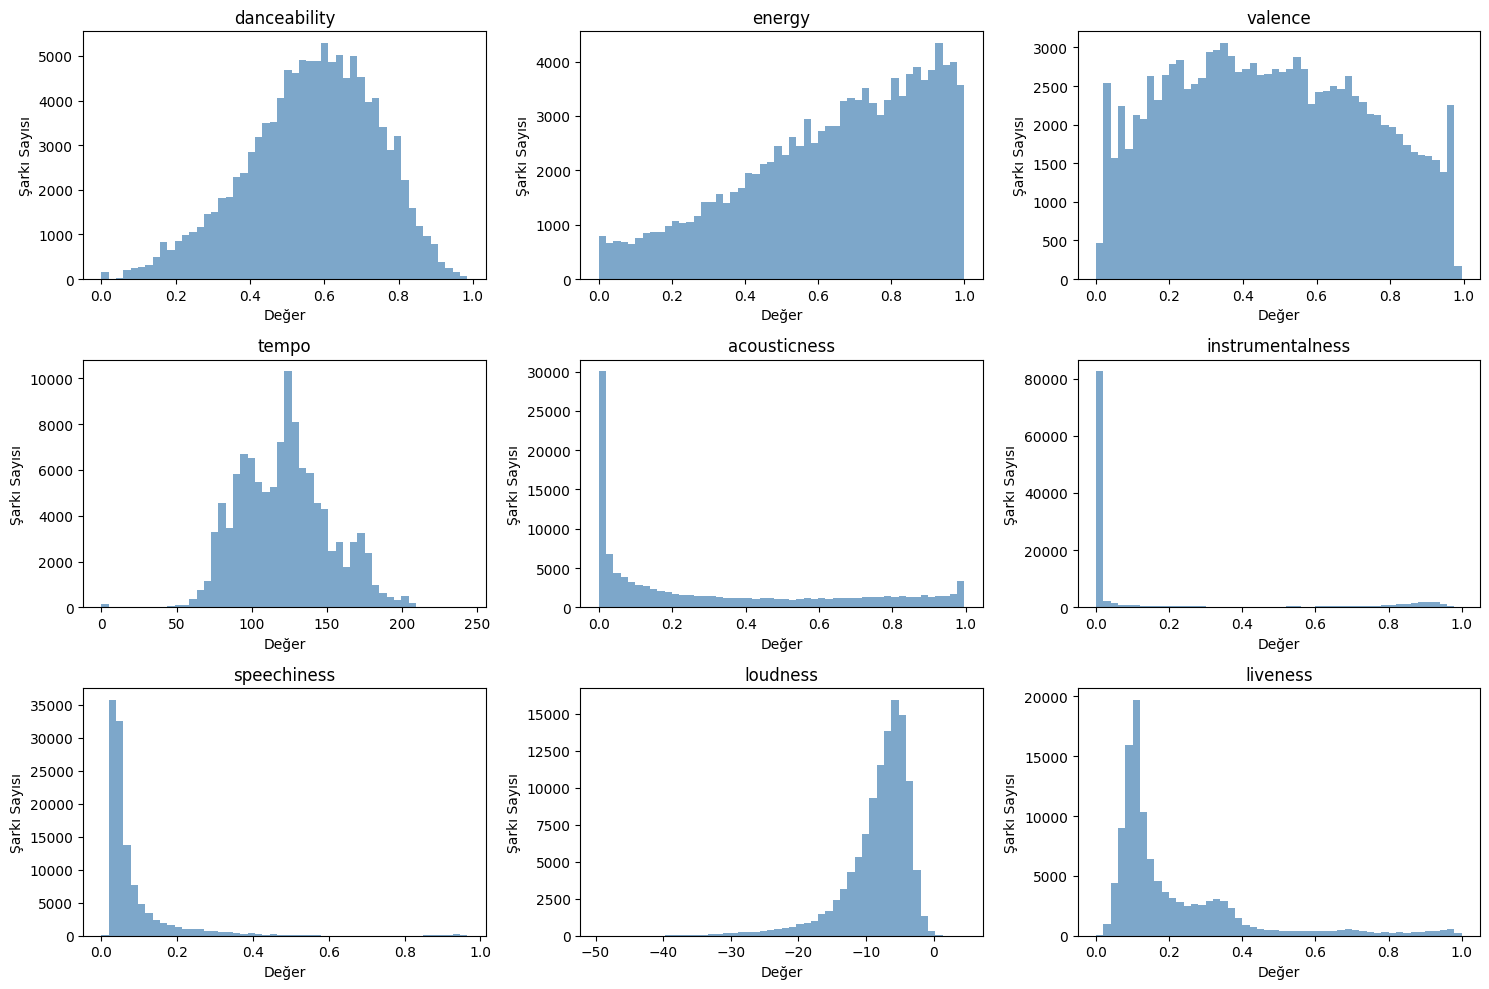

In [5]:
# Her özelliğin dağılımını göster
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=50, color='steelblue', alpha=0.7)
    axes[i].set_title(feature)
    axes[i].set_xlabel('Değer')
    axes[i].set_ylabel('Şarkı Sayısı')

plt.tight_layout()
plt.show()

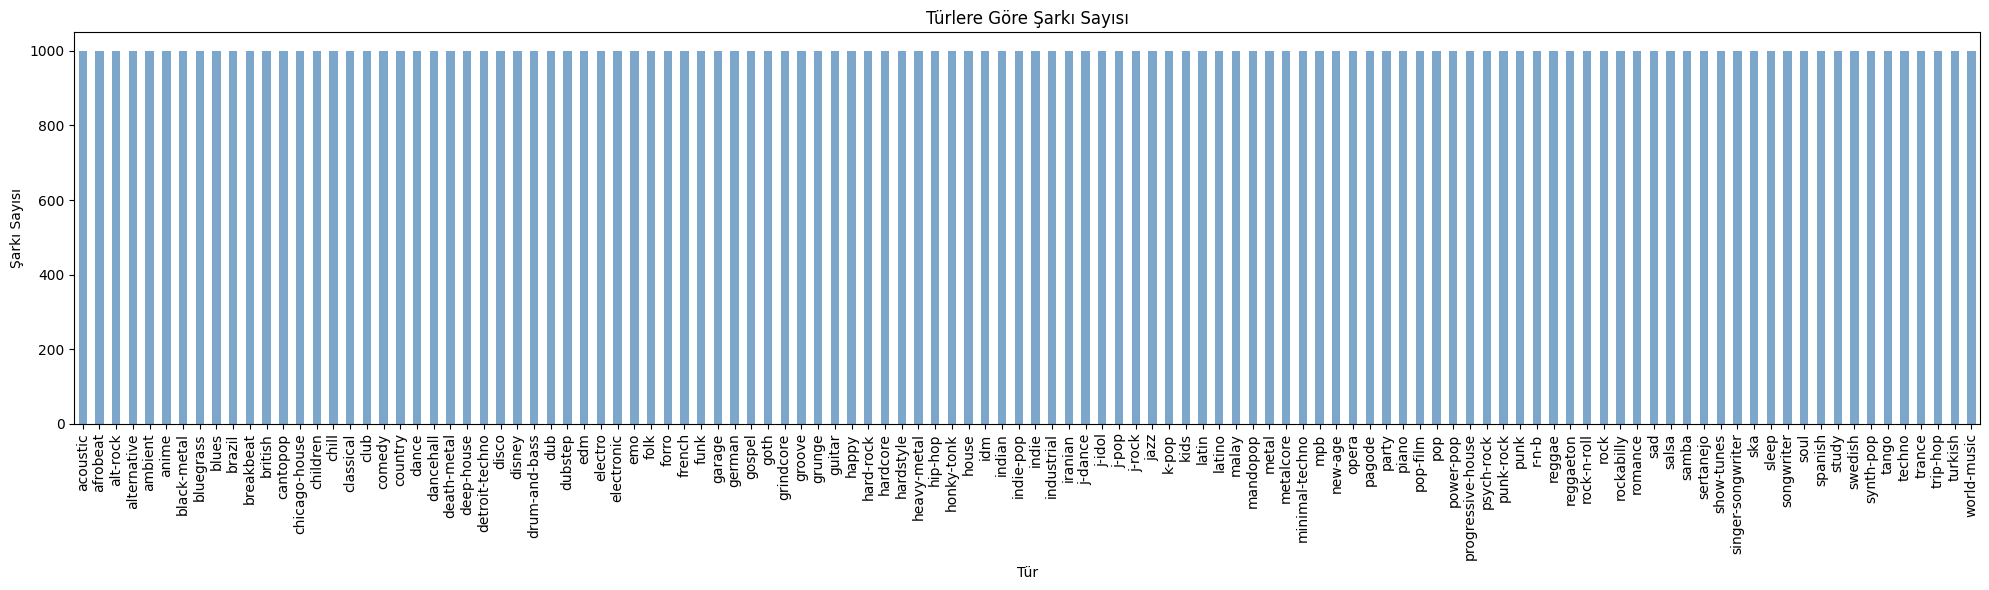

Toplam tür sayısı: 114


In [6]:
# Türlere göre dağılım
plt.figure(figsize=(20, 6))
df['track_genre'].value_counts().plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('Türlere Göre Şarkı Sayısı')
plt.xlabel('Tür')
plt.ylabel('Şarkı Sayısı')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Toplam tür sayısı:", df['track_genre'].nunique())

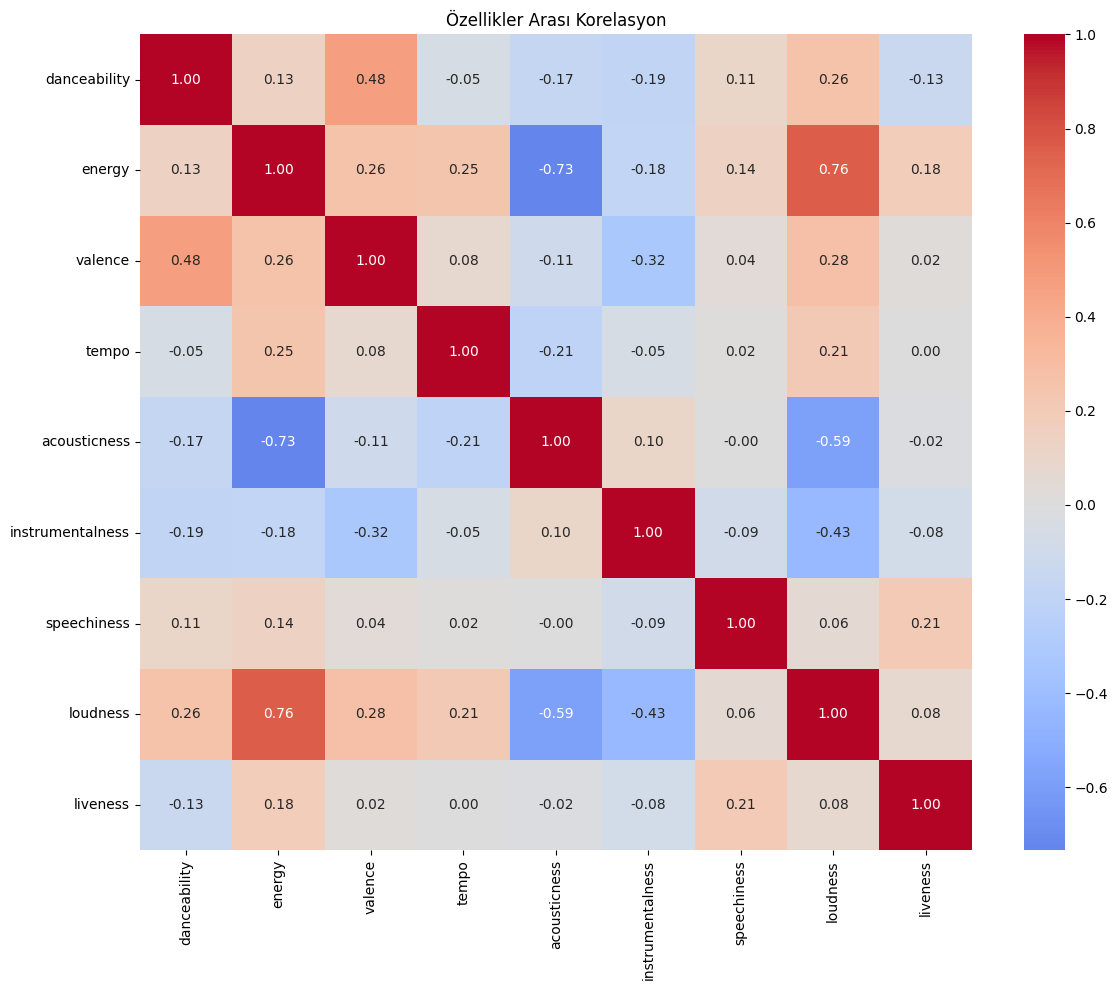

In [7]:
# Özellikler arası ilişkiyi göster
plt.figure(figsize=(12, 10))
korelasyon = df[features].corr()
sns.heatmap(korelasyon, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Özellikler Arası Korelasyon')
plt.tight_layout()
plt.show()

In [5]:
#clear data
df_clean = df.dropna()
df_clean = df_clean[df_clean['speechiness'] < 0.66  ] #to remove podcasts
df_clean = df_clean.drop_duplicates('track_id') #to remove duplicates
df_clean = df_clean.reset_index(drop=True) #to reset the index

print("Temizleme öncesi:", len(df),"şarkı")
print("Temizleme sonrası:", len(df_clean),"şarkı") 
print("Slinen şarkı sayısı:", len(df) - len(df_clean))


Temizleme öncesi: 114000 şarkı
Temizleme sonrası: 88871 şarkı
Slinen şarkı sayısı: 25129


In [6]:
# cleaned data
df_clean.to_csv('dataset_temiz.csv', index=False)
print("dataset_temiz.csv kaydedildi!")
print("Toplam şarkı:", len(df_clean))
print("Toplam tür:", df_clean['track_genre'].nunique())

dataset_temiz.csv kaydedildi!
Toplam şarkı: 88871
Toplam tür: 113


In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Kullanacağımız özellikler
features = [
    'danceability', 'energy', 'valence', 'tempo',
    'acousticness', 'instrumentalness', 
    'speechiness', 'loudness', 'liveness'
]

# Ham özellikleri al
X = df_clean[features].values

print("Normalize ÖNCE:")
print(f"Energy   — min: {X[:,1].min():.2f}, max: {X[:,1].max():.2f}")
print(f"Tempo    — min: {X[:,3].min():.2f}, max: {X[:,3].max():.2f}")
print(f"Loudness — min: {X[:,7].min():.2f}, max: {X[:,7].max():.2f}")

Normalize ÖNCE:
Energy   — min: 0.00, max: 1.00
Tempo    — min: 0.00, max: 243.37
Loudness — min: -49.53, max: 4.53


In [8]:
# Normalize et
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Normalize SONRA:")
print(f"Energy   — min: {X_scaled[:,1].min():.2f}, max: {X_scaled[:,1].max():.2f}")
print(f"Tempo    — min: {X_scaled[:,3].min():.2f}, max: {X_scaled[:,3].max():.2f}")
print(f"Loudness — min: {X_scaled[:,7].min():.2f}, max: {X_scaled[:,7].max():.2f}")

Normalize SONRA:
Energy   — min: -2.47, max: 1.42
Tempo    — min: -4.07, max: 4.03
Loudness — min: -7.87, max: 2.49


In [10]:
import joblib
import os

# Models klasörü oluştur
os.makedirs('models', exist_ok=True)

# Kaydet
joblib.dump(scaler, 'models/scaler.pkl')
np.save('models/X_scaled.npy', X_scaled)
df_clean.to_csv('models/df_clean.csv', index=False)

print("Kaydedildi:")
print("  models/scaler.pkl")
print("  models/X_scaled.npy")
print("  models/df_clean.csv")

Kaydedildi:
  models/scaler.pkl
  models/X_scaled.npy
  models/df_clean.csv


In [1]:
import torch

t = torch.tensor([1.0, 2.0, 3.0, 4.0, 5.0])
print("Tensor:", t)
print("Şekli:", t.shape)
print("Tipi:", t.dtype)

Tensor: tensor([1., 2., 3., 4., 5.])
Şekli: torch.Size([5])
Tipi: torch.float32


In [2]:
# requires_grad=True diyoruz
# "Bu tensor üzerindeki işlemleri takip et" demek
x = torch.tensor(3.0, requires_grad=True)

# Bir işlem yap
y = x ** 2  # y = x²

# Türevi hesapla
y.backward()

# dy/dx = 2x = 2*3 = 6 olmalı
print("x:", x)
print("y:", y)
print("dy/dx:", x.grad)

x: tensor(3., requires_grad=True)
y: tensor(9., grad_fn=<PowBackward0>)
dy/dx: tensor(6.)


In [3]:
import torch.nn as nn

# Basit bir sinir ağı katmanı
katman = nn.Linear(9, 1)
# 9 giriş (9 audio feature)
# 1 çıkış (beğenme skoru)

print("Katman:", katman)
print("Ağırlık şekli:", katman.weight.shape)
print("Bias şekli:", katman.bias.shape)

Katman: Linear(in_features=9, out_features=1, bias=True)
Ağırlık şekli: torch.Size([1, 9])
Bias şekli: torch.Size([1])


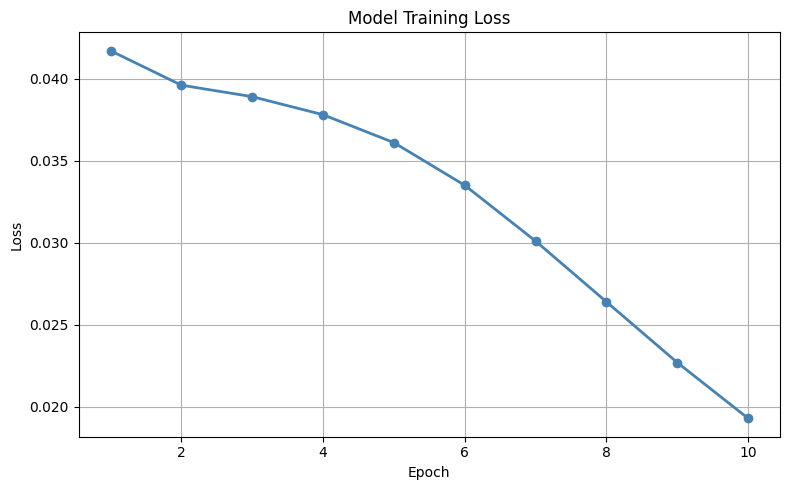

In [1]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6,7,8,9,10]
losses = [0.0417, 0.0396, 0.0389, 0.0378, 0.0361, 
          0.0335, 0.0301, 0.0264, 0.0227, 0.0193]

plt.figure(figsize=(8,5))
plt.plot(epochs, losses, marker='o', color='steelblue', linewidth=2)
plt.title('Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_grafigi.png')
plt.show()